# Corridor Two-Body Kinematic Plausibility Simulation

Author: Andrew Jelen<br>
Approach: 3-phase analytical decomposition of the contested two-body movement sequence in a 2 m corridor over 3 s, comparing the per-phase kinematic demands against published biomechanical reference distributions with 95% confidence intervals.

## Events reconstruction (3 phases over 3 s)

Corridor topology (V = Victoria, A = Andrew; `|` = wall/door, `..` = corridor space):

```
pre-timer    |V A .. |       A has approached V; both stand near the apartment door
t = 0.0 s    |V A .. |       timer starts
t = 1.0 s    | .. VA |       after pull
t = 2.0 s    | .. AV*|       after swap+throw; V's back impacts elevator door (*)
t = 3.0 s    | .. VA |       after swap-back; A ends at elevator with back to it
```

Initial positions: V at x=0.1 m (apartment doorway), A at x=0.5 m (just inside the corridor, in front of V). Both face the elevator at +x. V's facing direction tracks A continuously, rotating 180 degrees each time positions swap.

| # | Phase | Duration | V motion | A motion | Notes |
|---|---|---|---|---|---|
| 1 | Pull | 1.0 s | translates 1.5 m | retreats backward 1.3 m | A drags V toward elevator |
| 2 | Swap+throw | 1.0 s | translates 0.5 m + rotates 180 deg | swaps to V's other side | V's back impacts elevator door |
| 3 | Swap-back | 1.0 s | translates 0.5 m + rotates 180 deg | rotates 180 deg + translates 0.5 m | A ends at elevator with back to it |

Per-phase kinematic budgets derived directly from each phase's duration via the triangular velocity profile:

- v_peak = 2 * displacement / duration
- a_peak = 4 * displacement / duration^2
- F_peak = mass * a_peak
- impulse = mass * v_peak
- kinetic energy = 0.5 * mass * v_peak^2
- omega_peak = 2 * rotation_angle / duration

The analysis answers: what peak velocities, accelerations, forces, impulses, kinetic energies and angular velocities are *required* for each phase, and how do those values compare to what adult males in the relevant reference populations can actually produce?

## Scoring rubric

| z-score above reference mean | Verdict |
|---|---|
| z <= 1 | plausible |
| 1 < z <= 2 | strained |
| 2 < z <= 3 | implausible |
| z > 3 | extreme |

Two cooperation models are computed: **passive** (deadweight, no resistance) and **small resistance** (friction-equivalent counter-force plus active brake). Full reconstruction narrative in `docs/events_reconstruction.md`; impact-force analysis at the elevator door in `docs/impact_analysis.md`.


In [1]:
# Imports
from __future__ import annotations

import math  # standard library
from pathlib import Path

# Numerical / data
import numpy as np
import pandas as pd

# Plotting
import matplotlib.pyplot as plt
import seaborn as sns

# Rich console for tabular output
from rich.console import Console
from rich.table import Table

# Project modules
from henryk_simulations.corridor import (
    PhaseResult,
    PlausibilityScore,
    Verdict,
    compute_scenario,
    default_library,
    default_scenario,
    score_phase,
)
from henryk_simulations.corridor.kinematics import (
    G,
    actor_effort_for_translation,
    compute_phase_kinematics,
)
from henryk_simulations.corridor.plausibility import (
    score_reach_phase,
    score_rotation_phase,
    score_translation_phase,
)
from henryk_simulations.corridor.plots import (
    plot_acceleration_over_time,
    plot_corridor_overhead,
    plot_force_over_time,
    plot_impulse_over_time,
    plot_per_phase_demand,
    plot_phase_timeline,
    plot_reference_overlay,
    plot_speed_over_time,
    plot_verdict_summary,
)

console = Console()
sns.set_theme(style="whitegrid", context="notebook")
FIG_DIR = Path("../reports/figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)


2026-05-13 16:11:59.290 | INFO     | henryk_simulations.config:<module>:40 - PROJ_ROOT path is: /home/lab/workspace/private/henryk/henryk-simulations


In [2]:
# Reproducibility - bootstrap CIs sample from references
SEED = 42
np.random.seed(SEED)
rng = np.random.default_rng(SEED)


## Configuration

In [3]:
# Scenario configuration - per-phase time budget is editable here.
# Total time is the sum of phase durations; each phase's kinematic demand
# scales as v_peak = 2*s/t, a_peak = 4*s/t^2 so shorter phases mean higher
# required peaks.
PHASE_DURATIONS = {
    "pull":       1.0,  # s - A retreats backward pulling V toward elevator
    "swap-throw": 1.0,  # s - positions swap, V impacts elevator, V rotates 180 deg
    "swap-back":  1.0,  # s - positions swap back, A rotates 180 deg, V rotates 180 deg
}
sc = default_scenario(phase_durations=PHASE_DURATIONS)
lib = default_library()

cfg_table = Table(title="Scenario configuration", show_header=True, header_style="bold")
cfg_table.add_column("Parameter")
cfg_table.add_column("Value")
cfg_table.add_row("corridor width (door-to-door)", f"{sc.geometry.corridor_width:.2f} m")
cfg_table.add_row("corridor lateral", f"{sc.geometry.corridor_lateral:.2f} m")
cfg_table.add_row("Andrew mass", f"{sc.bodies.h_mass:.0f} kg")
cfg_table.add_row("Victoria mass", f"{sc.bodies.m_mass:.0f} kg")
cfg_table.add_row("Andrew yaw inertia", f"{sc.bodies.yaw_inertia_h:.2f} kg m^2")
cfg_table.add_row("Victoria yaw inertia", f"{sc.bodies.yaw_inertia_m:.2f} kg m^2")
cfg_table.add_row("total time", f"{sc.total_time:.2f} s")
cfg_table.add_row("phase count", f"{len(sc.phases)}")
console.print(cfg_table)


            Scenario configuration             
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┓
┃ Parameter                     ┃ Value       ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━┩
│ corridor width (door-to-door) │ 2.00 m      │
│ corridor lateral              │ 1.50 m      │
│ Andrew mass                   │ 90 kg       │
│ Victoria mass                 │ 70 kg       │
│ Andrew yaw inertia            │ 1.80 kg m^2 │
│ Victoria yaw inertia          │ 1.40 kg m^2 │
│ total time                    │ 3.00 s      │
│ phase count                   │ 3           │
└───────────────────────────────┴─────────────┘

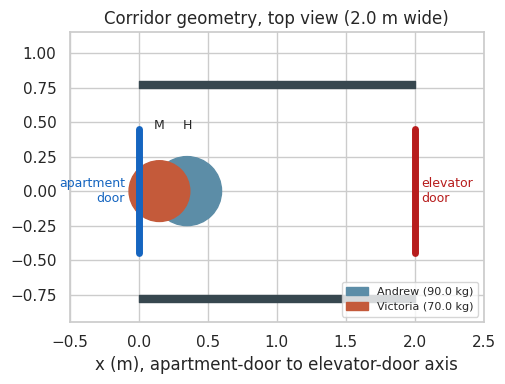

In [4]:
# Corridor overhead schematic
fig_corr = plot_corridor_overhead(
    sc.geometry,
    sc.bodies,
    out_path=FIG_DIR / "01-corridor-geometry.png",
)
plt.show()


## Phase decomposition

In [5]:
# Phase decomposition table
ph_table = Table(title="3-phase decomposition", show_header=True, header_style="bold")
for col in ("#", "phase", "kind", "body", "duration (s)", "translation (m)", "rotation (deg)", "notes"):
    ph_table.add_column(col)
notes_map = {
    "pull": "A retreats backward toward elevator pulling V along (1.5 m of V's 2 m total)",
    "swap-throw": "Positions exchange + V's back impacts elevator door + V rotates 180 deg tracking A",
    "swap-back": "Positions exchange back; A rotates 180 deg to face away (back to elevator); V rotates 180 deg",
}
for idx, phase in enumerate(sc.phases):
    deg = phase.rotation * 180 / math.pi if phase.rotation else 0
    ph_table.add_row(
        str(idx + 1),
        phase.name,
        phase.kind,
        phase.body,
        f"{phase.duration:.2f}",
        f"{phase.translation:.2f}" if phase.translation else "-",
        f"{deg:.0f}" if deg else "-",
        notes_map.get(phase.name, ""),
    )
console.print(ph_table)


                                               3-phase decomposition                                               
┏━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ # ┃ phase      ┃ kind      ┃ body ┃ duration (s) ┃ translation (m) ┃ rotation (deg) ┃ notes                     ┃
┡━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ 1 │ pull       │ translate │ M    │ 1.00         │ 1.50            │ -              │ A retreats backward       │
│   │            │           │      │              │                 │                │ toward elevator pulling V │
│   │            │           │      │              │                 │                │ along (1.5 m of V's 2 m   │
│   │            │           │      │              │                 │                │ total)                    │
│ 2 │ swap-throw │ translate │ M    │ 1.00         │ 0.22            │ 180            │ Positions exchange + V's  │
│   │            │           │      │              │                 │                │ back impacts elevator     │
│   │            │           │      │              │                 │                │ door + V rotates 180 deg  │
│   │            │           │      │              │                 │                │ tracking A                │
│ 3 │ swap-back  │ rotate    │ H    │ 1.00         │ -               │ 180            │ Positions exchange back;  │
│   │            │           │      │              │                 │                │ A rotates 180 deg to face │
│   │            │           │      │              │                 │                │ away (back to elevator);  │
│   │            │           │      │              │                 │                │ V rotates 180 deg         │
└───┴────────────┴───────────┴──────┴──────────────┴─────────────────┴────────────────┴───────────────────────────┘

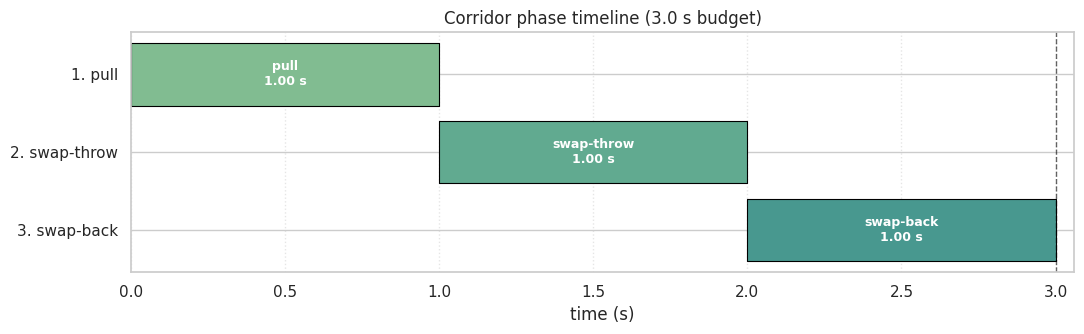

In [6]:
# Phase timeline gantt
fig_timeline = plot_phase_timeline(
    sc.phases,
    sc.phase_starts,
    total_time=sc.total_time,
    out_path=FIG_DIR / "01-phase-timeline.png",
)
plt.show()


## Kinematic demands per phase

In [7]:
# Per-phase kinematics, passive vs small-resistance
rows = []
for resistance in ("passive", "small"):
    results = compute_scenario(sc, resistance=resistance)
    for r in results:
        rows.append({
            "resistance": resistance,
            "phase": r.phase_name,
            "kind": r.kind,
            "body": r.body,
            "mass_kg": r.mass,
            "duration_s": r.duration,
            "distance_m": r.distance,
            "v_peak_m_s": round(r.v_peak, 3),
            "a_peak_m_s2": round(r.a_peak, 3),
            "a_peak_g": round(r.a_peak_g, 3),
            "f_peak_N": round(r.f_peak, 1),
            "f_resist_N": round(r.f_resist, 1),
            "impulse_N_s": round(r.impulse, 1),
            "ke_J": round(r.kinetic_energy, 1),
            "omega_peak_rad_s": round(r.omega_peak, 3),
            "alpha_peak_rad_s2": round(r.alpha_peak, 3),
            "torque_peak_Nm": round(r.torque_peak, 1),
            "rot_ke_J": round(r.rotational_ke, 1),
            "reach_v_peak_m_s": round(r.reach_v_peak, 3),
            "reach_f_peak_N": round(r.reach_f_peak, 1),
        })
results_df = pd.DataFrame(rows)
results_df.head(20)


,resistance,phase,kind,body,mass_kg,duration_s,distance_m,v_peak_m_s,a_peak_m_s2,a_peak_g,f_peak_N,f_resist_N,impulse_N_s,ke_J,omega_peak_rad_s,alpha_peak_rad_s2,torque_peak_Nm,rot_ke_J,reach_v_peak_m_s,reach_f_peak_N
0,passive,pull,translate,M,70.0,1.0,1.50,3.00,6.00,0.612,420.0,0.0,210.0,315.0,0.000,0.000,0.0,0.0,0.0,0.0
1,passive,swap-throw,translate,M,70.0,1.0,0.22,0.44,0.88,0.090,61.6,0.0,30.8,6.8,6.283,12.566,17.6,27.6,0.0,0.0
2,passive,swap-back,rotate,H,90.0,1.0,0.00,0.00,0.00,0.000,0.0,0.0,0.0,0.0,6.283,12.566,22.6,35.5,0.0,0.0
3,small,pull,translate,M,70.0,1.0,1.50,3.00,6.00,0.612,675.9,255.9,210.0,315.0,0.000,0.000,0.0,0.0,0.0,0.0
4,small,swap-throw,translate,M,70.0,1.0,0.22,0.44,0.88,0.090,317.5,255.9,30.8,6.8,6.283,12.566,17.6,27.6,0.0,0.0
5,small,swap-back,rotate,H,90.0,1.0,0.00,0.00,0.00,0.000,0.0,0.0,0.0,0.0,6.283,12.566,22.6,35.5,0.0,0.0


In [8]:
# Headline numbers for each phase based on its time budget
all_results = compute_scenario(sc, resistance="passive")
hdr_table = Table(title="Phase headline kinematics (passive, per time budget)", show_header=True, header_style="bold")
for col in ("phase", "duration (s)", "v_peak (m/s)", "a_peak (m/s^2, g)", "F_peak (N)", "KE (J)", "impulse (N s)", "omega_peak (rad/s)"):
    hdr_table.add_column(col)
for r in all_results:
    hdr_table.add_row(
        r.phase_name,
        f"{r.duration:.2f}",
        f"{r.v_peak:.2f}" if r.v_peak else "-",
        f"{r.a_peak:.2f} ({r.a_peak_g:.2f}g)" if r.a_peak else "-",
        f"{r.f_peak:.0f}" if r.f_peak else "-",
        f"{r.kinetic_energy:.0f}" if r.kinetic_energy else "-",
        f"{r.impulse:.0f}" if r.impulse else "-",
        f"{r.omega_peak:.2f}" if r.omega_peak else "-",
    )
console.print(hdr_table)


                               Phase headline kinematics (passive, per time budget)                                
┏━━━━━━━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┓
┃            ┃              ┃              ┃ a_peak        ┃            ┃        ┃               ┃ omega_peak     ┃
┃ phase      ┃ duration (s) ┃ v_peak (m/s) ┃ (m/s^2, g)    ┃ F_peak (N) ┃ KE (J) ┃ impulse (N s) ┃ (rad/s)        ┃
┡━━━━━━━━━━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━┩
│ pull       │ 1.00         │ 3.00         │ 6.00 (0.61g)  │ 420        │ 315    │ 210           │ -              │
│ swap-throw │ 1.00         │ 0.44         │ 0.88 (0.09g)  │ 62         │ 7      │ 31            │ 6.28           │
│ swap-back  │ 1.00         │ -            │ -             │ -          │ -      │ -             │ 6.28           │
└────────────┴──────────────┴──────────────┴───────────────┴────────────┴────────┴───────────────┴────────────────┘

In [9]:
# Actor effort and friction cap during the pull phase
throw = next(r for r in compute_scenario(sc, resistance="passive") if r.phase_name == "pull")
eff = actor_effort_for_translation(throw, actor_mass=sc.bodies.h_mass)
console.print("[bold]Actor effort budget[/bold]")
console.print(f"  required force on M : {eff['f_required_N']:.0f} N")
console.print(f"  friction cap (H mass {sc.bodies.h_mass:.0f} kg, mu 0.30): {eff['f_friction_cap_N']:.0f} N")
console.print(f"  feasible            : {eff['feasible']}")
console.print(f"  headroom ratio      : {eff['headroom_ratio']:.2f}")


Actor effort budget

required force on M : 420 N

friction cap (H mass 90 kg, mu 0.30): 265 N

feasible            : False

headroom ratio      : 0.63

## Reference distributions

In [10]:
# Reference distributions
ref_rows = []
for key, ref in lib.refs.items():
    lo, hi = ref.ci(0.95)
    ref_rows.append({
        "key": key,
        "name": ref.name,
        "units": ref.units,
        "mean": round(ref.mean, 3),
        "sd": round(ref.sd, 3),
        "ci95_lo": round(lo, 3),
        "ci95_hi": round(hi, 3),
        "population": ref.population,
        "citation": ref.citation,
    })
ref_df = pd.DataFrame(ref_rows)
ref_df


,key,name,units,mean,sd,ci95_lo,ci95_hi,population,citation
0,push_force_single_arm,"single-arm peak push, untrained male",N,400.0,100.0,204.004,595.996,"adult male, recreational",Daams 1994; Mital & Kumar 1995
1,push_force_two_arm,"two-arm peak push, standing",N,800.0,200.0,408.007,1191.993,"adult male, recreational",Daams 1994; Chaffin & Andersson 1991
2,sprint_acceleration_recreational,"sprint acceleration, recreational",m/s^2,3.0,0.8,1.432,4.568,"adult male, recreational","Mero, Komi & Gregor 1992; di Prampero 2005"
3,sprint_acceleration_elite,"sprint acceleration, elite sprinter",m/s^2,5.0,0.5,4.020,5.980,elite male sprinter,"Mero, Komi & Gregor 1992"
4,throw_velocity_object_5kg,"overhand throw velocity, 5 kg object",m/s,8.0,2.5,3.100,12.900,"adult male, recreational",Cross 2004; Atwater 1979
5,throw_kinetic_energy,"overhand throw KE budget, 5 kg object",J,160.0,80.0,3.203,316.797,"adult male, recreational",Cross 2004; van den Tillaar & Ettema 2004
6,yaw_angular_velocity_pivot,standing pivot yaw angular velocity,rad/s,3.5,1.0,1.540,5.460,"adult male, recreational","Hodgson, Lewis & Drury 2008"
7,whole_body_yaw_inertia,whole-body yaw moment of inertia,kg*m^2,1.5,0.4,0.716,2.284,"adult male, recreational","Plagenhoef, Evans & Abdelnour 1983"
8,arm_swing_velocity,arm swing forward velocity,m/s,2.5,0.8,0.932,4.068,"adult male, recreational","Marteniuk, MacKenzie & Leavitt 1990"


## Plausibility scoring

In [11]:
# Score each phase against the most appropriate reference for each kinematic demand
results_passive = compute_scenario(sc, resistance="passive")

# Map phase -> chosen references. A translate phase that also has a rotation
# (Victoria's 360 deg yaw during the throw) is scored for both quantities.
def score_all(results):
    scores: list[PlausibilityScore] = []
    for r in results:
        if r.kind == "translate" and r.f_peak > 0:
            scores += score_translation_phase(
                r,
                accel_ref=lib["sprint_acceleration_recreational"],
                force_ref=lib["push_force_two_arm"],
                energy_ref=lib["throw_kinetic_energy"] if r.phase_name in ("pull", "swap-throw") else None,
            )
        if r.omega_peak > 0:
            scores += score_rotation_phase(r, omega_ref=lib["yaw_angular_velocity_pivot"])
        if r.kind == "reach" and r.reach_v_peak > 0:
            scores += score_reach_phase(r, arm_ref=lib["arm_swing_velocity"])
    return scores

scores = score_all(results_passive)
score_df = pd.DataFrame([
    {
        "phase": s.phase_name,
        "quantity": s.quantity_label,
        "required": round(s.required_value, 3),
        "units": s.units,
        "ref": s.reference_name,
        "ref_mean": round(s.reference_mean, 3),
        "ref_sd": round(s.reference_sd, 3),
        "z": round(s.z, 2),
        "x_mean": round(s.multiple_of_mean, 2),
        "verdict": s.verdict.value,
    }
    for s in scores
])
score_df


,phase,quantity,required,units,ref,ref_mean,ref_sd,z,x_mean,verdict
0,pull,peak acceleration,6.000,m/s^2,"sprint acceleration, recreational",3.0,0.8,3.75,2.00,extreme
1,pull,peak force,420.000,N,"two-arm peak push, standing",800.0,200.0,-1.90,0.53,plausible
2,pull,kinetic energy,315.000,J,"overhand throw KE budget, 5 kg object",160.0,80.0,1.94,1.97,strained
3,swap-throw,peak acceleration,0.880,m/s^2,"sprint acceleration, recreational",3.0,0.8,-2.65,0.29,plausible
4,swap-throw,peak force,61.600,N,"two-arm peak push, standing",800.0,200.0,-3.69,0.08,plausible
5,swap-throw,kinetic energy,6.776,J,"overhand throw KE budget, 5 kg object",160.0,80.0,-1.92,0.04,plausible
6,swap-throw,peak yaw angular velocity,6.283,rad/s,standing pivot yaw angular velocity,3.5,1.0,2.78,1.80,implausible
7,swap-back,peak yaw angular velocity,6.283,rad/s,standing pivot yaw angular velocity,3.5,1.0,2.78,1.80,implausible


In [12]:
# Per-phase summary table: peak values + verdict bands per (phase, quantity)
summary_table = Table(title="Per-phase peak demands and verdicts", show_header=True, header_style="bold")
for col in ("phase", "quantity", "required", "ref mean +/- sd", "x mean", "z", "verdict"):
    summary_table.add_column(col)

verdict_style = {
    "plausible": "green",
    "strained": "yellow",
    "implausible": "red",
    "extreme": "bold red",
}
for s in scores:
    summary_table.add_row(
        s.phase_name,
        s.quantity_label,
        f"{s.required_value:,.2f} {s.units}",
        f"{s.reference_mean:.2f} +/- {s.reference_sd:.2f} {s.units}",
        f"{s.multiple_of_mean:.2f} x",
        f"{s.z:+.2f}",
        f"[{verdict_style.get(s.verdict.value, 'white')}]{s.verdict.value}[/]",
    )
console.print(summary_table)


                                    Per-phase peak demands and verdicts                                     
┏━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━━━━━━━┓
┃ phase      ┃ quantity                  ┃ required   ┃ ref mean +/- sd     ┃ x mean ┃ z     ┃ verdict     ┃
┡━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━━━━━━━┩
│ pull       │ peak acceleration         │ 6.00 m/s^2 │ 3.00 +/- 0.80 m/s^2 │ 2.00 x │ +3.75 │ extreme     │
│ pull       │ peak force                │ 420.00 N   │ 800.00 +/- 200.00 N │ 0.53 x │ -1.90 │ plausible   │
│ pull       │ kinetic energy            │ 315.00 J   │ 160.00 +/- 80.00 J  │ 1.97 x │ +1.94 │ strained    │
│ swap-throw │ peak acceleration         │ 0.88 m/s^2 │ 3.00 +/- 0.80 m/s^2 │ 0.29 x │ -2.65 │ plausible   │
│ swap-throw │ peak force                │ 61.60 N    │ 800.00 +/- 200.00 N │ 0.08 x │ -3.69 │ plausible   │
│ swap-throw │ kinetic energy            │ 6.78 J     │ 160.00 +/- 80.00 J  │ 0.04 x │ -1.92 │ plausible   │
│ swap-throw │ peak yaw angular velocity │ 6.28 rad/s │ 3.50 +/- 1.00 rad/s │ 1.80 x │ +2.78 │ implausible │
│ swap-back  │ peak yaw angular velocity │ 6.28 rad/s │ 3.50 +/- 1.00 rad/s │ 1.80 x │ +2.78 │ implausible │
└────────────┴───────────────────────────┴────────────┴─────────────────────┴────────┴───────┴─────────────┘

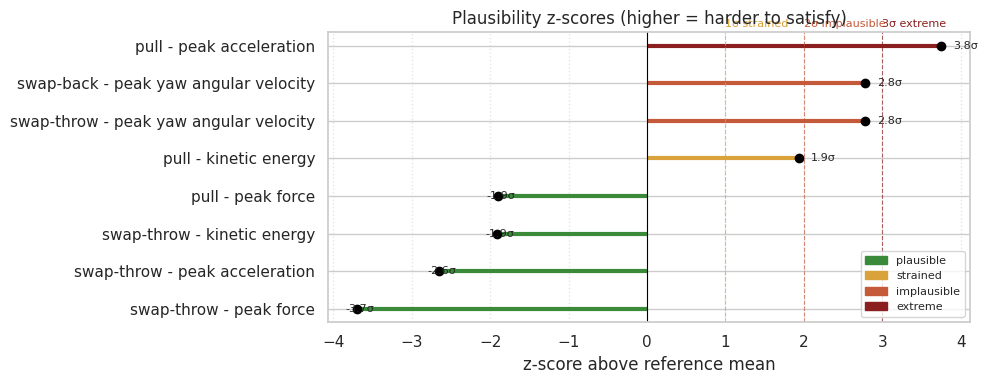

In [13]:
# Lollipop summary of z-scores
fig_verdict = plot_verdict_summary(scores, out_path=FIG_DIR / "01-verdict-summary.png")
plt.show()


## Visualisations

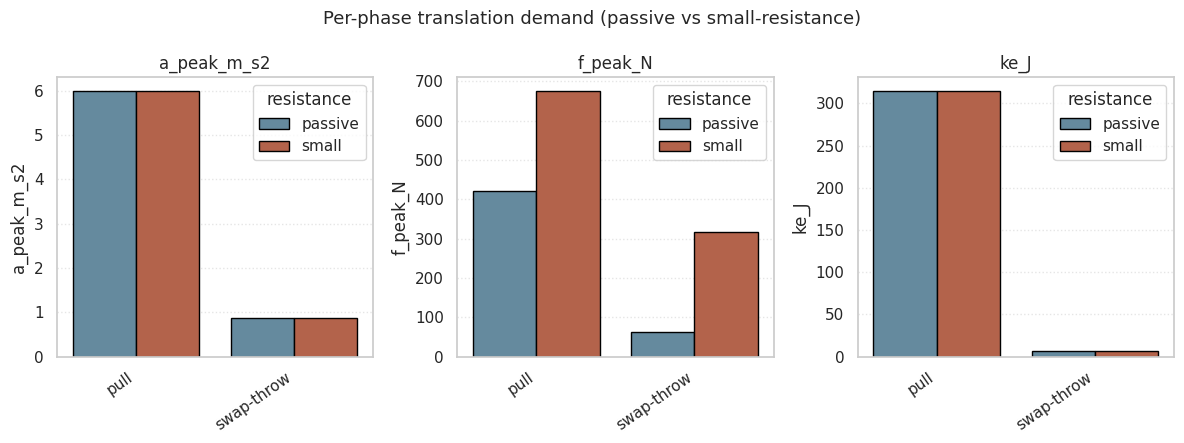

In [14]:
# Per-phase demand: acceleration, force, KE (passive vs small)
fig_demand = plot_per_phase_demand(
    results_df[results_df["a_peak_m_s2"] > 0],
    columns=["a_peak_m_s2", "f_peak_N", "ke_J"],
    out_path=FIG_DIR / "01-per-phase-demand.png",
    title="Per-phase translation demand (passive vs small-resistance)",
)
plt.show()


## Time-series: speed, acceleration, force, impulse

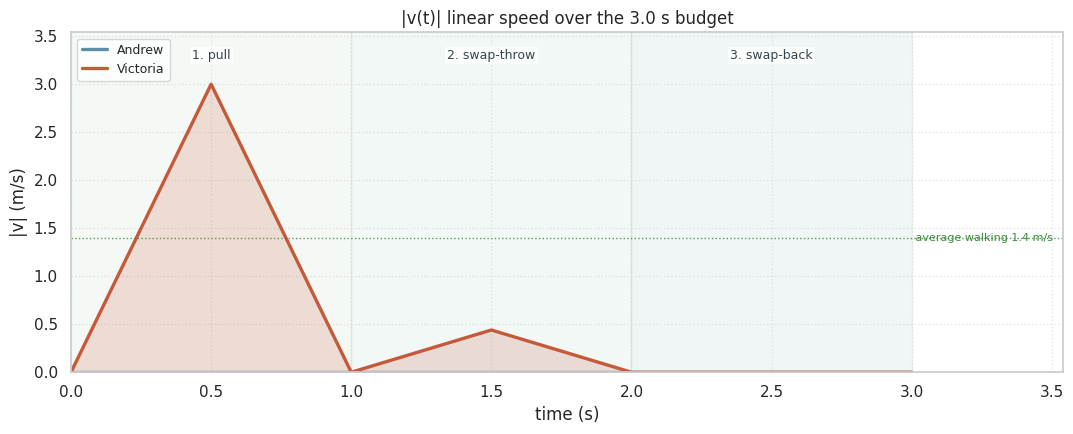

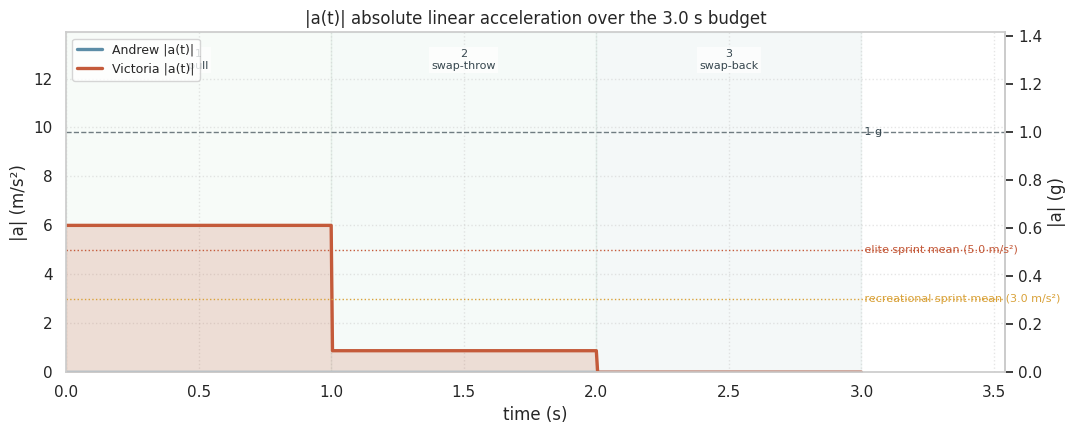

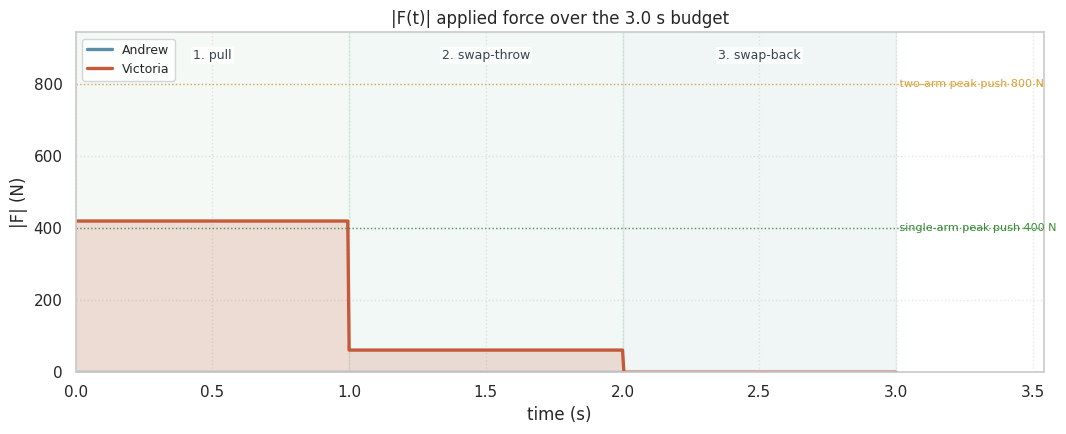

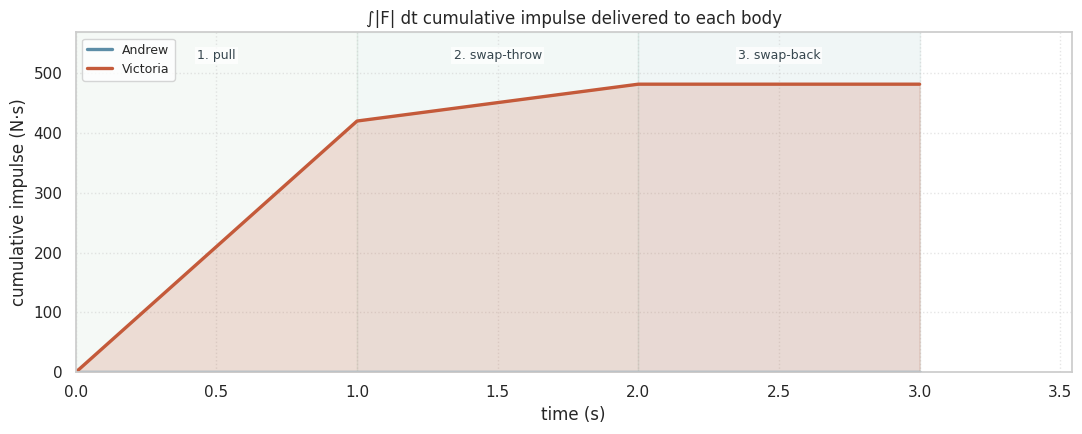

In [15]:
# Four time-series plots: speed, acceleration, force, cumulative impulse
fig_v = plot_speed_over_time(
    sc, results_passive, out_path=FIG_DIR / "01-speed-timeline.png"
)
plt.show()

fig_accel = plot_acceleration_over_time(
    sc, results_passive, out_path=FIG_DIR / "01-acceleration-timeline.png"
)
plt.show()

fig_F = plot_force_over_time(
    sc, results_passive, out_path=FIG_DIR / "01-force-timeline.png"
)
plt.show()

fig_p = plot_impulse_over_time(
    sc, results_passive, out_path=FIG_DIR / "01-impulse-timeline.png"
)
plt.show()


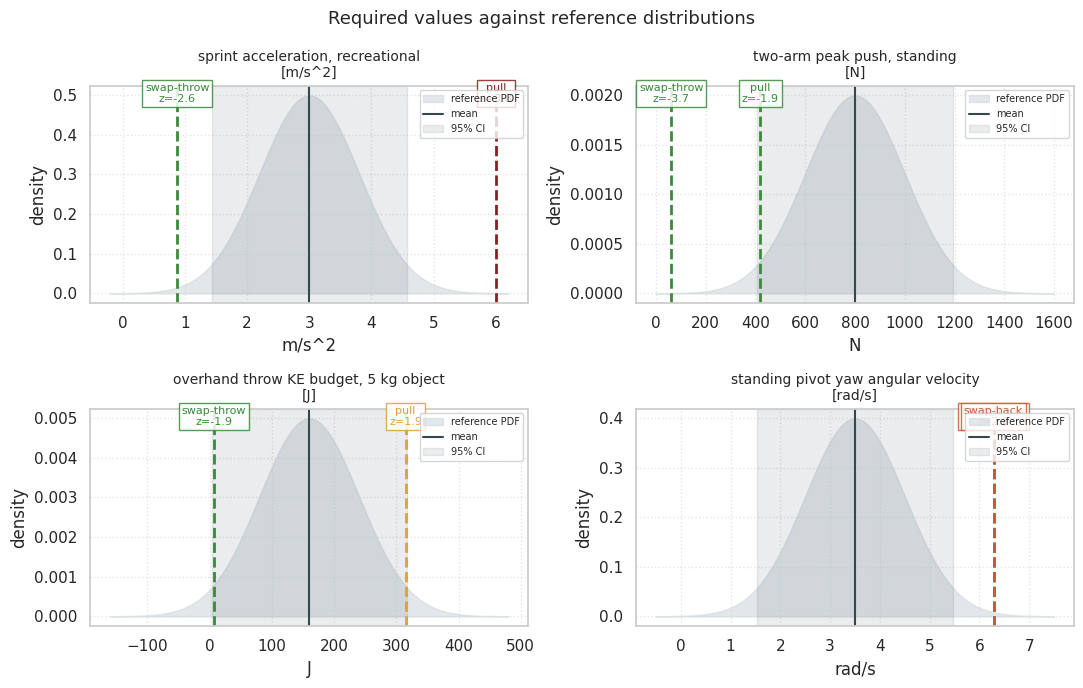

In [16]:
# Required values overlaid on reference distributions
# Pick the union of references that received at least one score
ref_used = []
for s in scores:
    if not any(r.name == s.reference_name for r in ref_used):
        ref_used.append(next(r for r in lib.refs.values() if r.name == s.reference_name))
fig_overlay = plot_reference_overlay(
    scores,
    ref_used,
    out_path=FIG_DIR / "01-reference-overlay.png",
)
plt.show()


## Throw energy budget

In [17]:
# Energy budget for the pull phase (largest translational demand)
throw_r = next(r for r in results_passive if r.phase_name == "pull")
push_budget_two_arm = lib["push_force_two_arm"].mean
throw_ke_ref = lib["throw_kinetic_energy"]

console.print(f"[bold]Throw energy budget[/bold]")
console.print(f"  kinetic energy delivered to M : {throw_r.kinetic_energy:,.0f} J")
console.print(f"  reference for 5 kg overhand throw: {throw_ke_ref.mean:.0f} +/- {throw_ke_ref.sd:.0f} J")
console.print(f"  multiple of reference mean     : {throw_r.kinetic_energy / throw_ke_ref.mean:.1f} x")
console.print(f"  z-score above reference mean   : {throw_ke_ref.z(throw_r.kinetic_energy):.1f}")
console.print(f"  force required (Newton 2nd law): {throw_r.f_peak:,.0f} N")
console.print(f"  two-arm push budget (Daams 1994): {push_budget_two_arm:,.0f} N")


Throw energy budget

kinetic energy delivered to M : 315 J

reference for 5 kg overhand throw: 160 +/- 80 J

multiple of reference mean     : 2.0 x

z-score above reference mean   : 1.9

force required (Newton 2nd law): 420 N

two-arm push budget (Daams 1994): 800 N

## Verdict tally and export

In [18]:
# Final verdict tally and export of the result table for the markdown report
verdict_counts = score_df["verdict"].value_counts().to_dict()
console.print("[bold]Verdict tally across all (phase, quantity) scores[/bold]")
for v in ("plausible", "strained", "implausible", "extreme"):
    console.print(f"  {v:14s}: {verdict_counts.get(v, 0)}")

implausible_or_worse = score_df[score_df["verdict"].isin(["implausible", "extreme"])]
console.print(f"\n[bold]implausible or extreme phases (z > 2):[/bold] {len(implausible_or_worse)}")
console.print(implausible_or_worse[["phase", "quantity", "required", "ref_mean", "z", "verdict"]].to_string(index=False))

# Persist for the verdict report
score_df.to_csv(FIG_DIR.parent / "01-phase-scores.csv", index=False)
results_df.to_csv(FIG_DIR.parent / "01-phase-kinematics.csv", index=False)


Verdict tally across all (phase, quantity) scores

plausible     : 4

strained      : 1

implausible   : 2

extreme       : 1

implausible or extreme phases (z > 2): 3

phase                  quantity  required  ref_mean    z     verdict
      pull         peak acceleration     6.000       3.0 3.75     extreme
swap-throw peak yaw angular velocity     6.283       3.5 2.78 implausible
 swap-back peak yaw angular velocity     6.283       3.5 2.78 implausible

## Summary

Refer to `reports/corridor-plausibility.md` for the narrative verdict and embedded figures. The per-phase scores and kinematic table are written to `reports/01-phase-scores.csv` and `reports/01-phase-kinematics.csv` for downstream use.

### Limitations

- Constant-acceleration (triangular velocity) profile per phase is the most charitable interpretation; smoother profiles would require higher peaks.
- Resistance model is a friction-equivalent + constant brake; it does not capture active resistance (lowering centre of mass, bracing, counter-rotation).
- Reference distributions are normal with adult male means and SDs; tail probabilities should be read as approximate.
- The analysis is purely kinematic plausibility against population biomechanics. It does not constitute a forensic conclusion about any specific event.
